# Notebook 3 — Standard Monte-Carlo Estimation
### Project: *Rare-Event Estimation in Water-Quality Control*

We now estimate the **rare-event probability**
\[ \gamma \;=\; P(X>\tau) \;=\; \mathbb E_f\!\big[\,\mathbb I(X>\tau)\,\big] \]
with the plain Monte-Carlo estimator: draw \(X_1,\dots,X_N\sim f\) and average the indicator,
\[ \hat\gamma_{MC} \;=\; \frac1N\sum_{i=1}^N \mathbb I(X_i>\tau). \]

\(\hat\gamma_{MC}\) is unbiased with variance \(\operatorname{Var}(\hat\gamma_{MC})=\gamma(1-\gamma)/N\).
Because each indicator is Bernoulli(\(\gamma\)) and \(\gamma\) is tiny, the **relative** error
\(\sqrt{\operatorname{Var}}/\gamma \approx 1/\sqrt{N\gamma}\) is enormous unless \(N\gamma\) is
large. With \(\gamma\approx10^{-4}\) we need \(N\gg10^{4}\) just to see *any* exceedances — this is
the rare-event problem this notebook makes concrete, and motivates Importance Sampling in
Notebook 4.

We draw the samples with our **own** Box–Muller generator (built from the uniform primitive in
Notebook 2); no built-in direct sampler is used.

In [1]:
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

SEED = 42
rng = np.random.default_rng(SEED)


def find_project_root() -> Path:
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / "data" / "water_potability.csv").exists():
            return cand
    if here.name == "notebooks":
        return here.parent
    return here


ROOT = find_project_root()
DATA_PATH = ROOT / "data" / "water_potability.csv"
RESULTS = ROOT / "results"
RESULTS.mkdir(parents=True, exist_ok=True)

### Load the fitted model from Notebook 1

In [2]:
pfile = RESULTS / "fitted_params.json"
if pfile.exists():
    params = json.load(open(pfile))
    print("Loaded model from results/fitted_params.json")
else:
    print("fitted_params.json not found -> re-fitting from the CSV (run Notebook 1 first "
          "to persist the model).")
    _df = pd.read_csv(DATA_PATH)
    _x = _df["Chloramines"].dropna().to_numpy()
    _mu, _sig = stats.norm.fit(_x)
    _tau = float(stats.norm.ppf(1 - 1e-4, _mu, _sig))
    params = {
        "target": "Chloramines", "best_model": "Normal", "scipy_dist": "norm",
        "params": [float(_mu), float(_sig)], "mu": float(_mu), "sigma": float(_sig),
        "tau": _tau, "gamma_true": float(stats.norm.sf(_tau, _mu, _sig)),
        "target_prob": 1e-4, "data_max": float(_x.max()),
    }

# Unpack the working model f(x): the fitted Normal N(mu, sigma)
DIST = getattr(stats, params["scipy_dist"])
PARAMS = tuple(params["params"])
mu, sigma = params["mu"], params["sigma"]
tau = params["tau"]
gamma_true = params["gamma_true"]


def f_pdf(z):
    """Target density f(x) = fitted N(mu, sigma)."""
    return DIST.pdf(z, *PARAMS)


print(f"Working model f(x): {params['best_model']}  mu={mu:.4f}  sigma={sigma:.4f}")
print(f"Threshold tau     : {tau:.4f}")
print(f"True probability  : gamma = P(X>tau) = {gamma_true:.3e}")

Loaded model from results/fitted_params.json
Working model f(x): Normal  mu=7.1223  sigma=1.5831
Threshold tau     : 13.0089
True probability  : gamma = P(X>tau) = 1.000e-04


### Manual samplers (uniform primitive only)

In [3]:
def box_muller(size, loc=0.0, scale=1.0, rng=rng):
    """Generate Normal samples from Uniform(0,1) numbers via the Box-Muller transform.

    This is OUR OWN normal generator: it uses only the uniform primitive, never
    scipy's .rvs() or np.random.normal. It is the manual sampler used for the large
    Monte-Carlo / Importance-Sampling loops.
    """
    m = (size + 1) // 2
    u1 = rng.random(m)
    u2 = rng.random(m)
    r = np.sqrt(-2.0 * np.log(u1))
    theta = 2.0 * np.pi * u2
    z = np.empty(2 * m)
    z[0::2] = r * np.cos(theta)
    z[1::2] = r * np.sin(theta)
    return loc + scale * z[:size]


def accept_reject(size, target_pdf, a, b, M=None, rng=rng, return_stats=False):
    """Draw `size` samples from `target_pdf` on [a, b] using a Uniform(a,b) proposal g.

    Condition used:  target_pdf(x) <= M * g(x)  with g(x) = 1/(b-a).
    If M is None it is estimated as (b-a) * max_x target_pdf(x) on a fine grid.
    Only the uniform primitive is used; the accept/reject loop is implemented by hand.
    """
    if M is None:
        gx = np.linspace(a, b, 20000)
        M = (b - a) * np.max(target_pdf(gx)) * 1.001  # small safety margin
    g = 1.0 / (b - a)
    out = np.empty(size)
    filled = 0
    n_proposed = 0
    while filled < size:
        batch = max(size - filled, 1000)
        Y = rng.uniform(a, b, batch)         # proposal draw  Y ~ g
        U = rng.random(batch)                # U ~ Uniform(0,1)
        accept = U <= target_pdf(Y) / (M * g)
        Ya = Y[accept]
        take = min(len(Ya), size - filled)
        out[filled:filled + take] = Ya[:take]
        filled += take
        n_proposed += batch
    if return_stats:
        return out, dict(M=M, n_proposed=n_proposed,
                         empirical_acc=size / n_proposed,
                         theoretical_acc=1.0 / M)
    return out

## 1. The Monte-Carlo estimator

`gamma_true` (computed analytically from the fitted CDF in Notebook 1) is our ground truth for
measuring the error of the simulation-based estimates.

In [4]:
def mc_estimate(N, rng=rng):
    """One standard Monte-Carlo estimate of gamma = P(X>tau)."""
    X = box_muller(N, loc=mu, scale=sigma, rng=rng)   # X ~ f
    return np.mean(X > tau)

# single demonstration run
demo = mc_estimate(1_000_000)
print(f"Single MC run, N=1e6 : gamma_hat = {demo:.3e}   (true gamma = {gamma_true:.3e})")

Single MC run, N=1e6 : gamma_hat = 1.190e-04   (true gamma = 1.000e-04)


## 2. Sample-size experiment and the rare-event problem

For each \(N\in\{10^3,10^4,10^5,10^6\}\) we repeat the estimate many times to measure the
estimator's **mean**, **standard deviation** and — crucially — how often it returns exactly
**zero** (no exceedance observed at all, \(\hat\gamma=0\)).

In [5]:
Ns = [10**3, 10**4, 10**5, 10**6]
reps_map = {10**3: 300, 10**4: 200, 10**5: 60, 10**6: 12}

rows = []
mc_runs = {}   # keep the raw estimates for the plots
for N in Ns:
    reps = reps_map[N]
    est = np.array([mc_estimate(N, rng) for _ in range(reps)])
    mc_runs[N] = est
    se_emp = est.std(ddof=1)
    se_theo = np.sqrt(gamma_true * (1 - gamma_true) / N)
    rows.append({
        "N": N,
        "reps": reps,
        "mean_estimate": est.mean(),
        "std (empirical SE)": se_emp,
        "theoretical SE": se_theo,
        "relative error": se_emp / gamma_true,
        "zero-estimates": int(np.sum(est == 0)),
        "% zero": 100 * np.mean(est == 0),
    })

mc_table = pd.DataFrame(rows).set_index("N")
mc_table_disp = mc_table.copy()
for c in ["mean_estimate", "std (empirical SE)", "theoretical SE"]:
    mc_table_disp[c] = mc_table_disp[c].map(lambda v: f"{v:.3e}")
mc_table_disp["relative error"] = mc_table_disp["relative error"].map(lambda v: f"{v:.2f}")
mc_table_disp

,reps,mean_estimate,std (empirical SE),theoretical SE,relative error,zero-estimates,% zero
N,,,,,,,
1000,300,8.000e-05,2.953e-04,3.162e-04,2.95,278,92.666667
10000,200,1.005e-04,1.000e-04,9.999e-05,1.00,71,35.500000
100000,60,1.005e-04,2.683e-05,3.162e-05,0.27,0,0.000000
1000000,12,1.044e-04,1.016e-05,9.999e-06,0.10,0,0.000000


Read the **% zero** column: at \(N=10^3\) the vast majority of runs never observe a single
exceedance, so they report \(\hat\gamma=0\) — a useless estimate with infinite relative error
on a log scale. The relative error only becomes acceptable once \(N\gamma\) is of order tens to
hundreds, i.e. \(N\gtrsim10^5\). This is the fundamental inefficiency of crude Monte-Carlo for
rare events.

## 3. Convergence plots

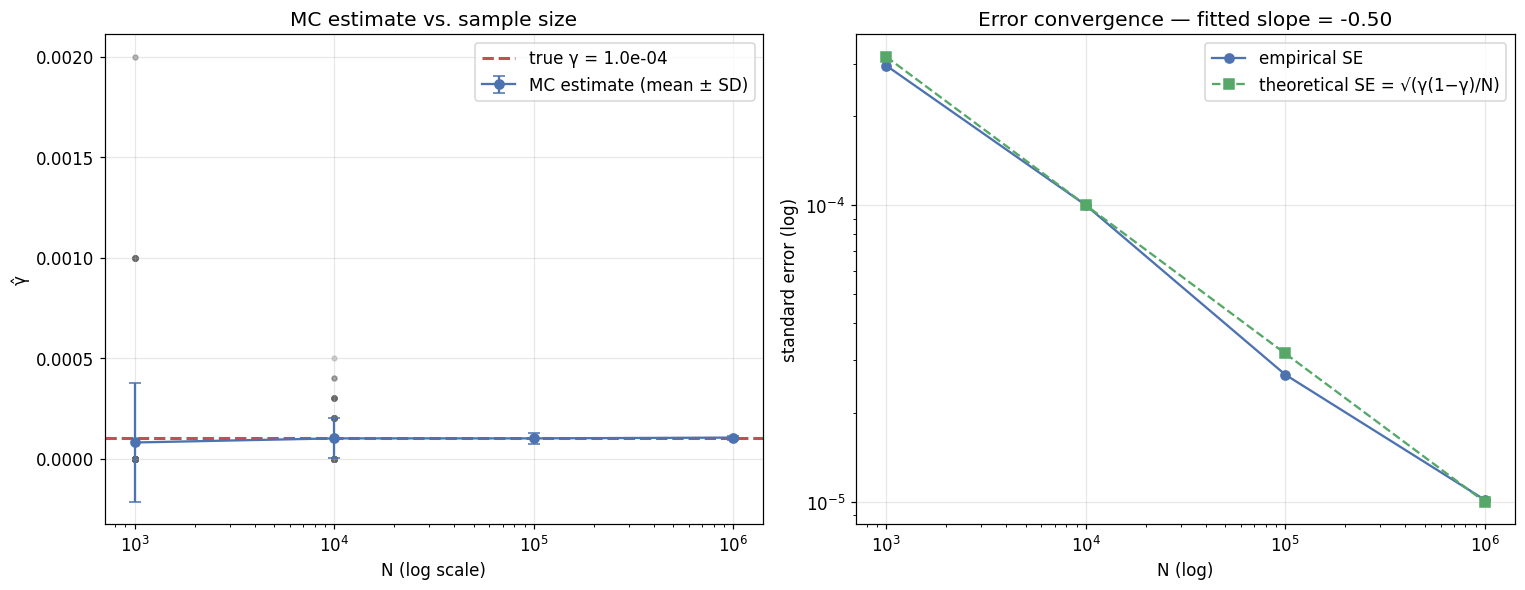

Fitted log-log slope of the MC standard error: -0.496  (theory: -0.5)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# (a) estimate vs N with mean +/- std, plus the true value
means = mc_table["mean_estimate"].values
stds = mc_table["std (empirical SE)"].values
axes[0].errorbar(Ns, means, yerr=stds, fmt="o-", capsize=4, color="#4C72B0",
                 label="MC estimate (mean ± SD)")
axes[0].axhline(gamma_true, color="#C44E52", ls="--", lw=2, label=f"true γ = {gamma_true:.1e}")
# scatter the individual noisy runs for the two smaller N
for N in [10**3, 10**4]:
    axes[0].scatter([N] * len(mc_runs[N]), mc_runs[N], s=10, alpha=0.25, color="0.4")
axes[0].set_xscale("log")
axes[0].set_xlabel("N (log scale)"); axes[0].set_ylabel("γ̂")
axes[0].set_title("MC estimate vs. sample size"); axes[0].legend()

# (b) log-log standard error vs N -> slope -1/2
se = mc_table["std (empirical SE)"].values
slope, intercept = np.polyfit(np.log10(Ns), np.log10(se), 1)
axes[1].loglog(Ns, se, "o-", color="#4C72B0", label="empirical SE")
axes[1].loglog(Ns, mc_table["theoretical SE"].values, "s--", color="#55A868",
               label="theoretical SE = √(γ(1−γ)/N)")
axes[1].set_xlabel("N (log)"); axes[1].set_ylabel("standard error (log)")
axes[1].set_title(f"Error convergence — fitted slope = {slope:.2f}")
axes[1].legend()
plt.tight_layout()
plt.savefig(RESULTS / "03_mc_convergence.png", bbox_inches="tight")
plt.show()

print(f"Fitted log-log slope of the MC standard error: {slope:.3f}  (theory: -0.5)")

## 4. Analytical Question 3 — the log–log slope

> *The slope of the error curve on a log–log plot indicates the convergence rate.*

The standard error of a Monte-Carlo estimator behaves like \(C\,N^{-1/2}\). Taking logs,
\(\log(\mathrm{SE}) = \log C - \tfrac12\log N\), so on a **log–log** plot the error is a straight
line with **slope \(-1/2\)** — exactly what we measured above. This rate is *independent of the
problem*: to halve the error you must **quadruple** \(N\). For a rare event the constant \(C\) is
also large (\(C=\sqrt{\gamma(1-\gamma)}\) gives a relative error \(\approx 1/\sqrt{N\gamma}\)),
which is why crude Monte-Carlo needs astronomically many samples here.

Importance Sampling (Notebook 4) keeps the same \(-1/2\) slope but **shrinks the constant \(C\)
by orders of magnitude**, reaching the same accuracy with far smaller \(N\).

In [7]:
mc_table.to_csv(RESULTS / "03_monte_carlo_results.csv")
print("Saved results/03_monte_carlo_results.csv")

Saved results/03_monte_carlo_results.csv


### Summary

* Implemented the unbiased MC estimator \(\hat\gamma_{MC}=\frac1N\sum \mathbb I(X_i>\tau)\).
* For \(\gamma\approx10^{-4}\), small \(N\) frequently yields \(\hat\gamma=0\) and huge relative
  error; reliability needs \(N\gtrsim10^5\).
* The error decays as \(N^{-1/2}\) (log–log slope \(\approx-0.5\)).

➡️ **Next:** Notebook 4 introduces **Importance Sampling** to attack exactly this inefficiency.